# Detector-only event view

Inspect the raw detector information for one event without running tracklet, vertex, or pattern reconstruction.

## Bootstrap project imports

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (candidate / "src").exists() and (candidate / "notebooks").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate reco_algorithm_tests project root.")

src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Project root: {PROJECT_ROOT}")


Project root: /workdir/playground/reco_algorithm_tests


## Import detector-view tools

In [2]:
from data_io import RecoDataFile, load_pioneer_libraries, print_file_creation_time
from figures import DetectorEventViewFigure
from pipeline import Pipeline
from pipeline.stages import EventInitStage, EventInputStage, InputContext


## Load PIONEER shared libraries

In [3]:
load_pioneer_libraries()

## Locate the current smoke-test ROOT file

In [4]:
DATA_DIR = (PROJECT_ROOT / ".data" / "current").resolve()
reco_file = str(DATA_DIR / "all_rec.root")

print_file_creation_time(reco_file)


The file '/workdir/playground/reco_algorithm_tests/.data/current/all_rec.root' was created on: 2026-06-17 14:48:17


## Open the reconstructed data file

In [5]:
reco_data = RecoDataFile(reco_file, profile="realistic")
print(f"Loaded {reco_data.entries} reconstructed events from {reco_file}")
print(f"Truth collections available: {reco_data.has_truth_entry}")


Loaded 727 reconstructed events from /workdir/playground/reco_algorithm_tests/.data/current/all_rec.root
Truth collections available: True


## Build the minimal pipeline needed to create an Event

In [6]:
pipeline = Pipeline()
pipeline.register_stage(EventInputStage())
pipeline.register_stage(EventInitStage())


## Load one event and initialize the detector-level Event object

In [7]:
event_index = 100
input_context = InputContext(reco_data, event_index)
pipeline.run_stage("input", input_context)
pipeline.run_stage("event_init")
event = pipeline.get_event()
print(event)


Event(id=100, no patterns, no tracklets, no vertices, 45 hits, extra_info: 1 keys: ['geo'], is_valid=False)


## Draw the detector event view

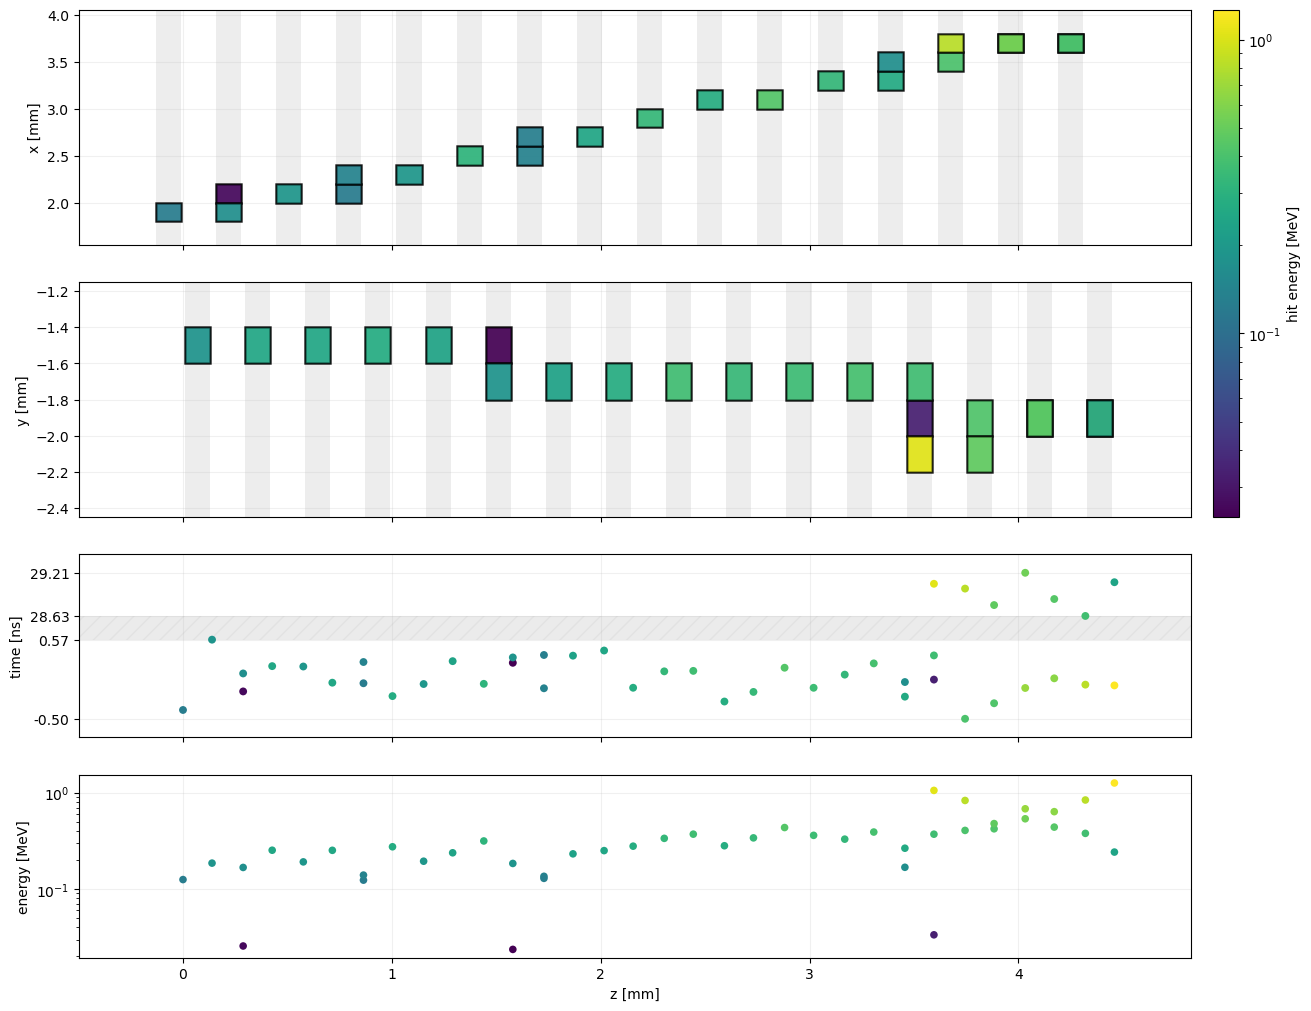

(<Figure size 1300x1000 with 5 Axes>,
 array([<Axes: ylabel='x [mm]'>, <Axes: ylabel='y [mm]'>,
        <Axes: ylabel='time [ns]'>,
        <Axes: xlabel='z [mm]', ylabel='energy [MeV]'>], dtype=object))

In [8]:
DetectorEventViewFigure().draw(event)